# 16. Fast Zero-Shot Fashion Pipeline (Grounding DINO + SAM 2 + FashionCLIP)

This notebook demonstrates the high-speed, LLM-free zero-shot fashion segmentation & classification pipeline designed for low-latency (< 1 second) execution.

### Pipeline Architecture
```text
                  Image
                    │
                    ▼
            Grounding DINO
    (Batched Broad Category Prompts)
                    │
          Candidate Bounding Boxes
                    │
               NMS Filtering
                    │
                    ▼
               SAM 2 (Batch)
   (Single Pass Box-Prompted Segmentation)
                    │
       Transparent Cutouts (RGBA PIL Images)
                    │
                    ▼
              FashionCLIP
   (Batch Crop Verification / Fine Classification)
                    │
                    ▼
     FastFashionPipelineResult (Pydantic V2)
```

Key Features:
- **Zero LLM Latency Overhead**: Removes LLM from inference loop.
- **Hierarchical Taxonomy**: Broad category localization followed by fine-grained FashionCLIP verification.
- **SAM 2 Batch Box Segmentation**: Processes all candidate boxes in a single forward pass.
- **Pydantic V2 In-Memory Outputs**: Returns `DetectedFashionObject` instances with transparent RGBA PIL Image cutouts without disk I/O.



## Step 1: Environment & Module Setup


In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

# Ensure project root is in python path
sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector import (
    FastFashionPipeline,
    DetectedFashionObject,
    FastFashionPipelineResult,
    CATEGORY_HIERARCHY,
    get_broad_categories,
    get_fine_categories_for_broad,
    get_parent_taxonomy_for_fine,
)

print("Environment setup successfully initialized.")

Environment setup successfully initialized.


## Step 2: Inspect Category Taxonomy Hierarchy


In [2]:
print("Top-level Broad Categories:")
print(get_broad_categories())

print("\nHierarchical Taxonomy Structure:")
for broad, subcats in CATEGORY_HIERARCHY.items():
    print(f"\n{broad}:")
    for subcat, fine_list in subcats.items():
        print(f" ├── {subcat}: {fine_list}")



Top-level Broad Categories:
['Clothing', 'Footwear', 'Accessories', 'Bags']

Hierarchical Taxonomy Structure:

Clothing:
 ├── Dresses: ['dresses', 'jumpsuits', 'skirts']
 ├── Tops: ['tops', 'shirts', 't shirts', 'sweaters']
 ├── Bottoms: ['shorts', 'pants', 'jeans']
 ├── Outerwear: ['jackets', 'blazers', 'jackets blazers', 'coats', 'suits', 'suits sets']

Footwear:
 ├── Sneakers: ['sneakers']
 ├── Boots: ['boots']
 ├── Sandals: ['sandals', 'heels', 'flats', 'loafers', 'mules slides', 'dress shoes']

Accessories:
 ├── Hats: ['hats']
 ├── Watches: ['watches']
 ├── Belts: ['belts', 'sunglasses', 'wallets', 'scarves', 'scarves shawls', 'ties', 'jewelry', 'earrings', 'necklaces', 'bracelets', 'rings', 'brooches']

Bags:
 ├── Tote: ['tote bags', 'handle bags', 'clutches']
 ├── Backpack: ['backpacks']
 ├── Crossbody: ['crossbody bags', 'shoulder bags', 'messenger bags', 'belt bags', 'briefcases', 'duffel bags']


## Step 3: Initialize & Warm Up Fast Pipeline


In [3]:
# Initialize Configuration
config = Config("config/config.yaml")

# Initialize Fast Pipeline with SAM 2
pipeline = FastFashionPipeline(
    config=config,
    box_threshold=0.25,
    text_threshold=0.25,
    sam_model_name="facebook/sam2.1-hiera-small",
    use_broad_category_batches=True,
)

# Pre-load models into memory/GPU
pipeline.load_models()
print("FastFashionPipeline initialized and ready!")



[2026-07-24 12:12:07] [INFO] [fashion_detector:config.py:169] - Configuration loaded from config/config.yaml. Device set to: mps
[2026-07-24 12:12:07] [INFO] [fashion_detector:fast_pipeline.py:121] - Warming up fast pipeline models (Grounding DINO, SAM2, FashionCLIP)...
[2026-07-24 12:12:07] [INFO] [fashion_detector:grounding_dino.py:33] - Loading Grounding DINO model: IDEA-Research/grounding-dino-tiny on device: mps


Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

[2026-07-24 12:12:13] [INFO] [fashion_detector:grounding_dino.py:46] - Grounding DINO model loaded successfully.
[2026-07-24 12:12:13] [INFO] [fashion_detector:sam3_segmenter.py:29] - Loading SAM 2 model: facebook/sam2.1-hiera-small on device: mps


Loading weights:   0%|          | 0/357 [00:00<?, ?it/s]

[2026-07-24 12:12:20] [INFO] [fashion_detector:sam3_segmenter.py:40] - SAM 2 model loaded successfully.
[2026-07-24 12:12:20] [INFO] [fashion_detector:fashion_clip.py:33] - Loading FashionCLIP model: patrickjohncyh/fashion-clip on device: mps


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[2026-07-24 12:12:24] [INFO] [fashion_detector:fashion_clip.py:46] - FashionCLIP model loaded successfully.
[2026-07-24 12:12:24] [INFO] [fashion_detector:fast_pipeline.py:125] - Fast pipeline models warm-up complete.
FastFashionPipeline initialized and ready!


## Step 4: Run Inference & Retrieve Processed & Annotated Images


In [4]:
sample_images = [
    "/Users/sunnyraj/Downloads/images-3.jpeg",
    "/Users/sunnyraj/Downloads/images-2.jpeg",
    "/Users/sunnyraj/Downloads/images.jpeg",
]
# Process sample image
test_image_path = sample_images[1]
print(f"Running FastFashionPipeline on: {test_image_path}...")

result: FastFashionPipelineResult = pipeline.process(test_image_path)

print(f"\nPipeline Result Summary:")
print(f"- Total Objects Detected: {result.total_objects}")
print(f"- Processing Time (Latency): {result.processing_time_ms:.2f} ms")
print(f"- Image Dimensions: {result.image_size}")
print(f"- Processed Input Image : {result.processed_image}")
print(f"- Annotated Image Obj   : {result.annotated_image}")

Running FastFashionPipeline on: /Users/sunnyraj/Downloads/images-2.jpeg...
[2026-07-24 12:12:24] [INFO] [fashion_detector:utils.py:204] - Loading image from local path: /Users/sunnyraj/Downloads/images-2.jpeg
[2026-07-24 12:12:24] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 12:12:24] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 12:12:25] [INFO] [fashion_detector:grounding_dino.py:149] - Grounding DINO detected 4 items.
[2026-07-24 12:12:25] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.3381 seconds
[2026-07-24 12:12:25] [INFO] [fashion_detector:fast_pipeline.py:202] - Batched Grounding DINO detected 4 raw proposals, reduced to 4 after NMS.
[2026-07-24 12:12:25] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.3427 seconds
[2026-07-24 12:12:25] [INFO] [fashion_detector:logging.py:98] - Starting: SAM 2 Batch Box 

/Users/sunnyraj/code_files/git_repos/image-segments/sam3_venv/.venv/lib/python3.12/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


[2026-07-24 12:12:26] [INFO] [fashion_detector:logging.py:103] - Completed: sam2_box_extraction in 0.3980 seconds
[2026-07-24 12:12:26] [INFO] [fashion_detector:logging.py:103] - Completed: SAM 2 Batch Box Segmentation in 0.4001 seconds
[2026-07-24 12:12:26] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Batch Crop Verification
[2026-07-24 12:12:26] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Crop Classification
[2026-07-24 12:12:26] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Text Embeddings
[2026-07-24 12:12:26] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Text Embeddings in 0.4536 seconds
[2026-07-24 12:12:26] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Crop Classification in 0.5015 seconds
[2026-07-24 12:12:26] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Batch Crop Verification in 0.5022 seconds
[2026-07-24 12:12:26] [INFO] [fashion_detector:fast_pipeline.py:364

## Step 5: Render Processed Input Image & Interactive Visualizations



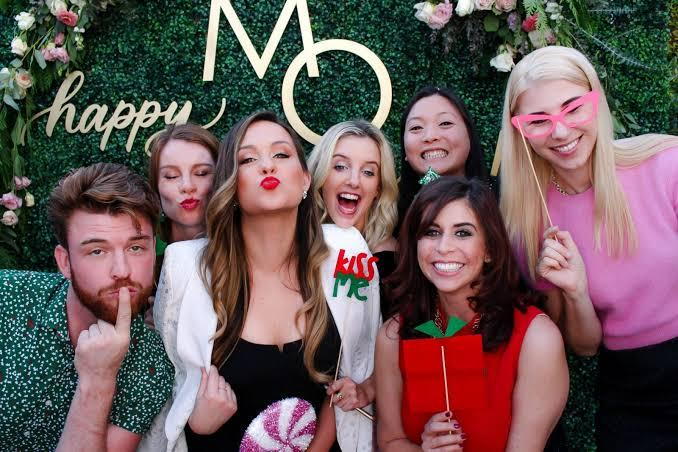

In [5]:
from fashion_detector.utils import (
    load_image,
    visualize_detections,
    display_img,
    user_categories,
    mapped_user_categories,
    execute_detection,
    clean_categories,
    display_imageGrid
)
visualize_detections(result.processed_image, result.objects)

Processed RGB Input Image:


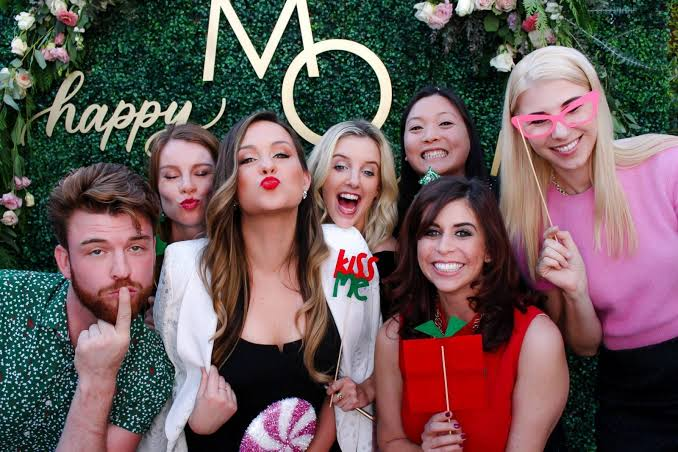

Annotated Image (Bounding Boxes + Labels):


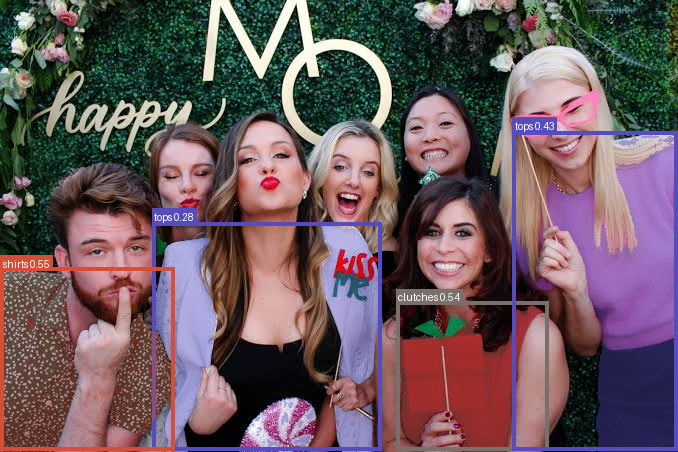

In [6]:
# 1. Display the exact RGB Input Image processed by the pipeline:
print("Processed RGB Input Image:")
display(result.processed_image)

# 2. Display the Annotated Image with Bounding Boxes & Labels drawn on top:
print("Annotated Image (Bounding Boxes + Labels):")
display(result.annotated_image)

# # 3. Render Interactive Clickable Overlay in Jupyter:
# print("Interactive HTML Visualization:")
# result.visualize(mode="interactive")



=== Detected 4 Fashion Items ===

Item #1:
  - Verified Fine Label : tops
  - Category Taxonomy  : Clothing -> Tops
  - Confidence Score   : 0.2822
  - Bounding Box [xyxy]: [152.1, 222.8, 381.7, 450.8]
  - Transparent Cutout : PIL Image (239, 235) (Mode: RGBA)


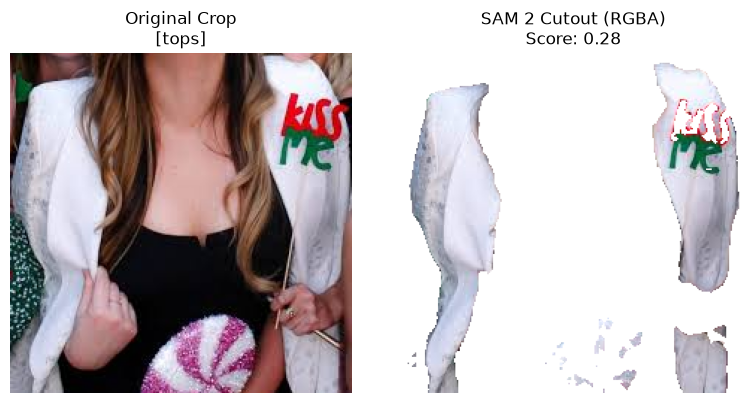


Item #2:
  - Verified Fine Label : shirts
  - Category Taxonomy  : Clothing -> Tops
  - Confidence Score   : 0.5518
  - Bounding Box [xyxy]: [0.7, 267.9, 174.8, 450.9]
  - Transparent Cutout : PIL Image (179, 190) (Mode: RGBA)


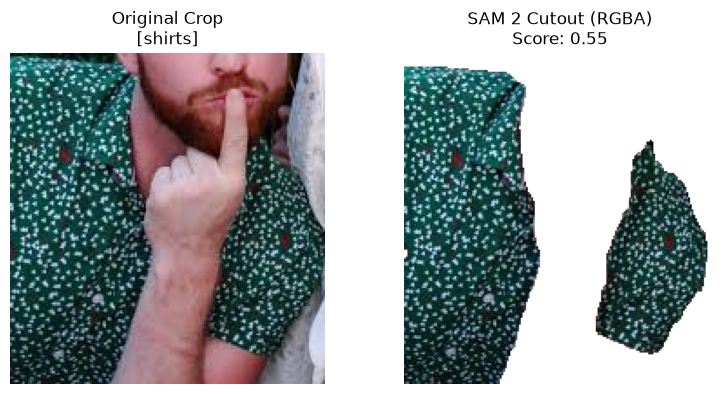


Item #3:
  - Verified Fine Label : clutches
  - Category Taxonomy  : Bags -> Tote
  - Confidence Score   : 0.5374
  - Bounding Box [xyxy]: [396.3, 301.2, 548.0, 450.9]
  - Transparent Cutout : PIL Image (162, 156) (Mode: RGBA)


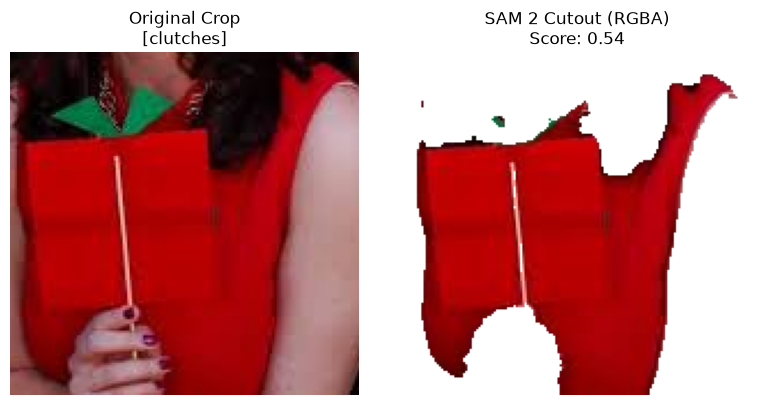


Item #4:
  - Verified Fine Label : tops
  - Category Taxonomy  : Clothing -> Tops
  - Confidence Score   : 0.4270
  - Bounding Box [xyxy]: [512.9, 131.8, 677.3, 450.5]
  - Transparent Cutout : PIL Image (171, 326) (Mode: RGBA)


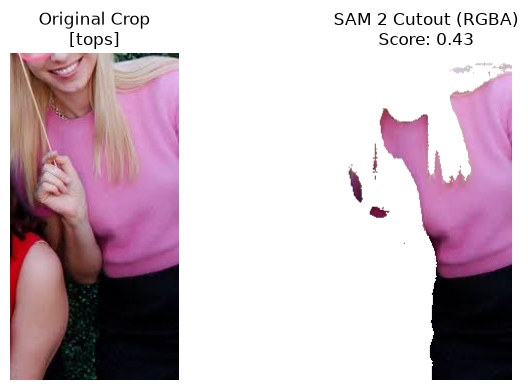

In [7]:
# Load original image for side-by-side display
orig_img = Image.open(test_image_path).convert("RGB")

print(f"=== Detected {result.total_objects} Fashion Items ===")

for idx, obj in enumerate(result.objects):
    print(f"\nItem #{idx + 1}:")
    print(f"  - Verified Fine Label : {obj.label}")
    print(f"  - Category Taxonomy  : {obj.broad_category} -> {obj.subcategory}")
    print(f"  - Confidence Score   : {obj.score:.4f}")
    print(f"  - Bounding Box [xyxy]: {[round(c, 1) for c in obj.box]}")
    print(f"  - Transparent Cutout : PIL Image {obj.image.size} (Mode: {obj.image.mode})")

    # Plot original crop vs transparent SAM2 cutout
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    # Bounding box crop from original image
    xmin, ymin, xmax, ymax = map(int, obj.box)
    box_crop = orig_img.crop((xmin, ymin, xmax, ymax))
    
    axes[0].imshow(box_crop)
    axes[0].set_title(f"Original Crop\n[{obj.label}]")
    axes[0].axis("off")

    # Transparent SAM2 cutout
    axes[1].imshow(obj.image)
    axes[1].set_title(f"SAM 2 Cutout (RGBA)\nScore: {obj.score:.2f}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

## Step 6: Multi-Person & Multi-Object Test


In [8]:
# Test on multi-object image
multi_image_path = "data/multiple_people.jpg"
if os.path.exists(multi_image_path):
    print(f"Running pipeline on multi-person image: {multi_image_path}...")
    result_multi = pipeline.process(multi_image_path)

    print(f"\nDetected {result_multi.total_objects} items in {result_multi.processing_time_ms:.2f} ms:")
    for obj in result_multi.objects:
        print(f"  - {obj.label.capitalize()} ({obj.broad_category} > {obj.subcategory}) | Score: {obj.score:.2f}")



Running pipeline on multi-person image: data/multiple_people.jpg...
[2026-07-24 12:12:27] [INFO] [fashion_detector:utils.py:204] - Loading image from local path: data/multiple_people.jpg
[2026-07-24 12:12:27] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Batched Detection
[2026-07-24 12:12:27] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 12:12:28] [INFO] [fashion_detector:grounding_dino.py:149] - Grounding DINO detected 8 items.
[2026-07-24 12:12:28] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.1517 seconds
[2026-07-24 12:12:28] [INFO] [fashion_detector:fast_pipeline.py:202] - Batched Grounding DINO detected 8 raw proposals, reduced to 5 after NMS.
[2026-07-24 12:12:28] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Batched Detection in 1.1526 seconds
[2026-07-24 12:12:28] [INFO] [fashion_detector:logging.py:98] - Starting: SAM 2 Batch Box Segmentation
[2026-07-

## Step 7: Inspect Pydantic V2 Schema Model Serialization


In [9]:
import json
# Demonstrate Pydantic V2 dict export (excluding raw binary arrays for clean JSON)
schema_dict = {
    "total_objects": result.total_objects,
    "processing_time_ms": result.processing_time_ms,
    "image_size": result.image_size,
    "objects": [
        {
            "label": obj.label,
            "broad_category": obj.broad_category,
            "subcategory": obj.subcategory,
            "score": obj.score,
            "box": obj.box,
            "metadata": obj.metadata,
        }
        for obj in result.objects
    ],
}

print("Pydantic V2 Result Serialization Example:")
print(json.dumps(schema_dict, indent=2))



Pydantic V2 Result Serialization Example:
{
  "total_objects": 4,
  "processing_time_ms": 2273.46,
  "image_size": [
    678,
    452
  ],
  "objects": [
    {
      "label": "tops",
      "broad_category": "Clothing",
      "subcategory": "Tops",
      "score": 0.28217053413391113,
      "box": [
        152.0753936767578,
        222.82296752929688,
        381.6648864746094,
        450.7513122558594
      ],
      "metadata": {
        "proposal_label": "clothing",
        "proposal_score": 0.45274442434310913,
        "fashion_clip_score": 0.28217053413391113
      }
    },
    {
      "label": "shirts",
      "broad_category": "Clothing",
      "subcategory": "Tops",
      "score": 0.5517871975898743,
      "box": [
        0.6610283851623535,
        267.8972473144531,
        174.84896850585938,
        450.8558349609375
      ],
      "metadata": {
        "proposal_label": "clothing",
        "proposal_score": 0.41506150364875793,
        "fashion_clip_score": 0.5517871975898